In the sequel we demonstrate with a simple task of learning a one dimensional parabola the way how models are built within Keras for the deep heding or deep portfolio optimization task:

In [ ]:
import numpy as np
import tensorflow as tf

from keras.models import Sequential
from keras.layers import Input, Dense, Conv2D, Concatenate, Dropout, Subtract, \
                        Flatten, MaxPooling2D, Multiply, Lambda, Add, Dot
from keras import optimizers

from keras.models import Model
from keras.layers import Input
from keras import initializers
from keras.constraints import max_norm
import keras.backend as K

import matplotlib.pyplot as plt

In [ ]:
#Definition of neural networks for heding strategies

N=1
m = 1 # dimension of price
d = 2 # number of layers in strategy
n = 2**14  # nodes in the first but last layers

# architecture is the same for all networks
layers = []
for j in range(N):
    for i in range(d):
        if i < d-1:
            nodes = n
            layer = Dense(nodes, activation='relu',trainable=True,
                      kernel_initializer=initializers.RandomNormal(0,1),#kernel_initializer='random_normal',
                      bias_initializer=initializers.RandomUniform(-1,1),
                      name=str(i)+str(j))
        else:
            nodes = m
            layer = Dense(nodes, activation='linear', trainable=True,
                          kernel_initializer=initializers.RandomNormal(0,1/n),#kernel_initializer='random_normal',
                          bias_initializer=initializers.RandomNormal(0,0),
                          name=str(i)+str(j))
        layers = layers + [layer]


In [ ]:
#Implementing the loss function
# Inputs is the training set below, containing the price S0,
#the initial hedging being 0, and the increments of the log price process
nn_input = Input(shape=(m,))

inputs = [nn_input]

for j in range(N):
    intermediate = nn_input
    for k in range(d):
        intermediate= layers[k+(j)*d](intermediate)

inputs = inputs
outputs= intermediate

model_ff = Model(inputs=inputs, outputs=outputs)

In [ ]:
model_ff.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 00 (Dense)                      │ (None, 16384)          │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 10 (Dense)                      │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,153 (192.00 KB)

 Trainable params: 49,153 (192.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
Ktrain = 10**4

xtrain = np.random.normal(0,0.2,(Ktrain,1))
ytrain = np.sin(10*xtrain)+np.random.normal(0,0.0,(Ktrain,1))

In [ ]:
opt = optimizers.SGD(learning_rate=0.0001)
model_ff.compile(optimizer=opt,loss='mean_squared_error')

In [ ]:
model_ff.fit(x=xtrain,y=ytrain, epochs=10,verbose=True,batch_size=100)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1913
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1796
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1688
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1580
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1500
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1387
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1312
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1253
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1148
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1112


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


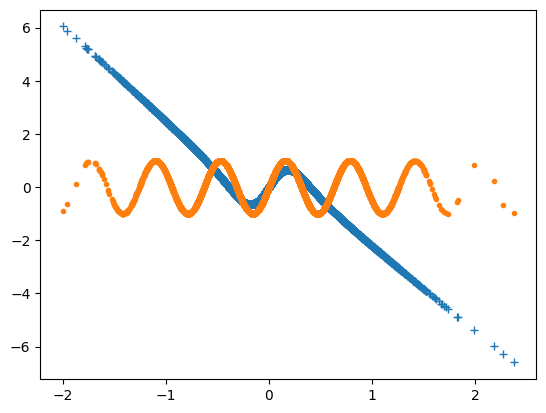

In [ ]:
Ktest = 2*10**4

xtest = np.random.normal(0,0.5,(Ktest,1))
ytest = np.sin(10*xtest)


plt.plot(xtest,model_ff.predict(xtest),'+')
plt.plot(xtest,ytest,'.')
#plt.plot(xtrain,ytrain,'+')
plt.show()